<font size="5">Section 2: non linear models</font>

# Housekeeping

## import libraries

Pandas for data management, statsmodels, numpy and sklearn for analysis, matplotlib for visualization. Other libraries as needed for specific tasks (e.g. semopy for SEM). Remember to use the bash terminal or the enviroment manager to add libraries.

## read data

Read data files using pandas as noted below. We can clean and organize data in many ways (for example, using the **dropna** command over a dataset).

## describe data

There are many was to analyze data and do descriptive statistics. A good command to start is ***head***, to describe a section of the data.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import sklearn
import scipy 
from scipy.stats import nbinom
import seaborn as sns
from statsmodels.iolib.summary2 import summary_col

import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

In [ ]:
# higher ed data
demre = pd.read_csv('../data/Adm2024.csv', delimiter=";", decimal=',')
demre.dropna(inplace=True)
VIAC = [1,2,3,4]
TIPO = ["REGULAR", "BEA", "PACE", "+MC"]
demre['TIPO'] = demre['VIA'].replace(VIAC, TIPO)
demre["PRA"] = (demre["PREFERENCIA"]== 1).astype(int)
demre.dtypes

ID_aux             object
CODIGO_UNIV         int64
CODIGO              int64
VIA                 int64
PREFERENCIA         int64
PTJE_POND         float64
TIPO_MATRICULA      int64
TIPO               object
PRA                 int64
dtype: object

In [ ]:
demre.reset_index(drop=True, inplace=True)
demre= demre[demre['PTJE_POND'] != 0]
demre.head()

,ID_aux,CODIGO_UNIV,CODIGO,VIA,PREFERENCIA,PTJE_POND,TIPO_MATRICULA,TIPO,PRA
0,id_690126976014,51,51111,1,1,709.90,1,REGULAR,1
1,id_831408370144,18,18075,1,1,713.45,1,REGULAR,1
2,id_752607579265,44,44049,1,1,876.10,1,REGULAR,1
3,id_772307770236,21,21043,1,1,643.30,2,REGULAR,1
4,id_481904877199,41,41067,1,1,638.70,1,REGULAR,1


<Axes: xlabel='PTJE_POND', ylabel='Density'>

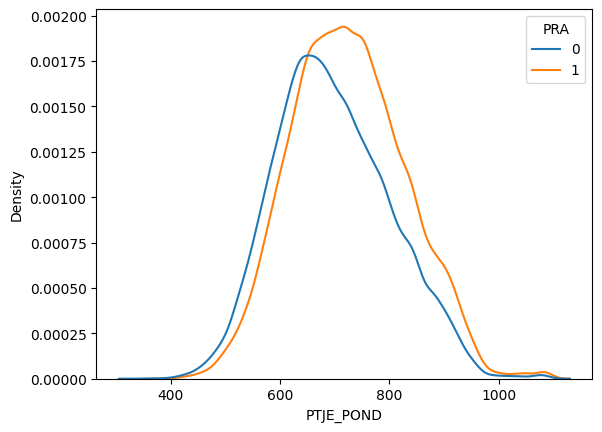

In [ ]:
sns.kdeplot(data=demre, x="PTJE_POND", hue="PRA")

### OLS

We can use statsmodels to estimate a simple OLS regression (linear probability model). 

In [ ]:
model = smf.ols("PRA ~ PTJE_POND*C(VIA) +C(CODIGO_UNIV, Treatment(13))", data=demre).fit(cov_type='HC1')
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    PRA   R-squared:                       0.085
Model:                            OLS   Adj. R-squared:                  0.085
Method:                 Least Squares   F-statistic:                     232.8
Date:                Tue, 31 Mar 2026   Prob (F-statistic):               0.00
Time:                        11:48:31   Log-Likelihood:                -78323.
No. Observations:              115353   AIC:                         1.568e+05
Df Residuals:                  115301   BIC:                         1.573e+05
Df Model:                          51                                         
Covariance Type:                  HC1                                         
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
In

### Probit



In [ ]:
probit_model = smf.probit("PRA ~ PTJE_POND*C(TIPO, Treatment(reference='REGULAR'))", data=demre).fit(cov_type='HC1')
print(probit_model.summary())

mfx = probit_model.get_margeff()
print(mfx.summary())

Optimization terminated successfully.
         Current function value: 0.681557
         Iterations 4
                          Probit Regression Results                           
Dep. Variable:                    PRA   No. Observations:               115353
Model:                         Probit   Df Residuals:                   115345
Method:                           MLE   Df Model:                            7
Date:                Tue, 31 Mar 2026   Pseudo R-squ.:                 0.01355
Time:                        11:48:31   Log-Likelihood:                -78620.
converged:                       True   LL-Null:                       -79700.
Covariance Type:                  HC1   LLR p-value:                     0.000
                                                                coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------------------
Intercept     

### Logit

In [ ]:
logit_model = smf.logit("PRA ~ PTJE_POND*C(TIPO, Treatment(reference='REGULAR'))", data=demre).fit()
print(logit_model.summary())

mfx = logit_model.get_margeff()
print(mfx.summary())

Optimization terminated successfully.
         Current function value: 0.681547
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:                    PRA   No. Observations:               115353
Model:                          Logit   Df Residuals:                   115345
Method:                           MLE   Df Model:                            7
Date:                Tue, 31 Mar 2026   Pseudo R-squ.:                 0.01357
Time:                        11:48:32   Log-Likelihood:                -78618.
converged:                       True   LL-Null:                       -79700.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                                coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------------------
Intercept     

### Poisson

(array([84375., 18629.,  6147.,  2695.,  1394.,   869.,   531.,   341.,
          230.,   142.]),
 array([ 1. ,  2.9,  4.8,  6.7,  8.6, 10.5, 12.4, 14.3, 16.2, 18.1, 20. ]),
 <BarContainer object of 10 artists>)

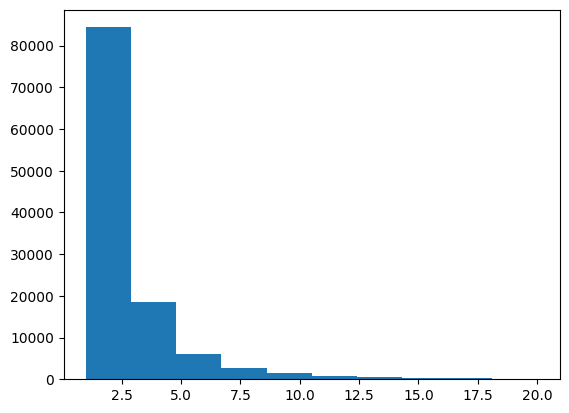

In [ ]:
plt.hist(demre.PREFERENCIA)

In [ ]:
poisson = smf.poisson("PREFERENCIA ~ PTJE_POND*C(TIPO, Treatment(reference='REGULAR')) + C(CODIGO_UNIV)", data=demre).fit()
print(poisson.summary())

Optimization terminated successfully.
         Current function value: 1.963580
         Iterations 8
                          Poisson Regression Results                          
Dep. Variable:            PREFERENCIA   No. Observations:               115353
Model:                        Poisson   Df Residuals:                   115301
Method:                           MLE   Df Model:                           51
Date:                Tue, 31 Mar 2026   Pseudo R-squ.:                 0.02979
Time:                        11:48:34   Log-Likelihood:            -2.2650e+05
converged:                       True   LL-Null:                   -2.3346e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                                coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------------------
Intercept     

In [ ]:
demre['ppredictions'] = poisson.predict(demre).astype(float)
print(demre.ppredictions)

0         2.825263
1         1.587058
2         2.040361
3         2.491098
4         2.636393
            ...   
118354    1.818845
118355    2.277479
118356    2.464773
118357    1.829443
118358    2.749922
Name: ppredictions, Length: 115353, dtype: float64


### Negative Binomial

In [ ]:
nbin = smf.negativebinomial("PREFERENCIA ~ PTJE_POND*C(TIPO, Treatment(reference='REGULAR')) + C(CODIGO_UNIV)", data=demre).fit()
print(nbin.summary())

         Current function value: 1.859915
         Iterations: 35
         Function evaluations: 44
         Gradient evaluations: 44
                     NegativeBinomial Regression Results                      
Dep. Variable:            PREFERENCIA   No. Observations:               115353
Model:               NegativeBinomial   Df Residuals:                   115301
Method:                           MLE   Df Model:                           51
Date:                Tue, 31 Mar 2026   Pseudo R-squ.:                 0.01968
Time:                        11:48:41   Log-Likelihood:            -2.1455e+05
converged:                      False   LL-Null:                   -2.1885e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                                coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------

In [ ]:
demre['predictions'] = nbin.predict(demre).astype(float)
print(demre.predictions)

0         2.829990
1         1.583185
2         2.044518
3         2.493258
4         2.638288
            ...   
118354    1.816810
118355    2.274879
118356    2.469915
118357    1.833747
118358    2.749545
Name: predictions, Length: 115353, dtype: float64


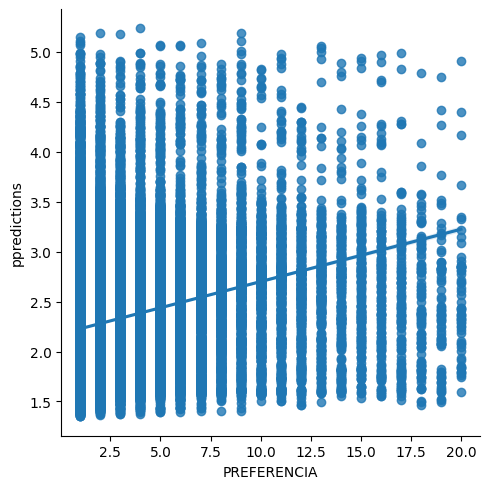

In [ ]:
sns.lmplot(x='PREFERENCIA', y='ppredictions', data=demre)

In [ ]:
demre['sres']=(demre['PREFERENCIA']-demre['ppredictions'])**2
demre['sres'].sum()/115345

np.float64(5.136694199325585)

### Test overdispersion

A simple test for overdispersion can be determined with the results of the Poisson model, using the ratio of Pearson chi2 / Df Residuals. A value larger than 1 indicates overdispersion.

The Negative Binomial model estimated above jointly with $\alpha$. In some applications we need to determine the appropiate value of $\alpha$, so you can estimate a simple regression using the output of the Poisson model:

1. Construct the following variable aux=$[(y-\lambda)^2-\lambda]/\lambda$
2. Regress the variable aux with $\lambda$ as the only explanatory variable (no constant)
3. The estimated value is an appropiate guess for $\alpha$


In [ ]:
aux=((demre['PREFERENCIA']-demre['ppredictions'])**2-demre['ppredictions'])/demre['ppredictions']
auxr=sm.OLS(aux,demre['ppredictions']).fit()
print(auxr.summary())

                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.017
Model:                            OLS   Adj. R-squared (uncentered):              0.017
Method:                 Least Squares   F-statistic:                              1966.
Date:                Tue, 31 Mar 2026   Prob (F-statistic):                        0.00
Time:                        11:52:36   Log-Likelihood:                     -4.2004e+05
No. Observations:              115353   AIC:                                  8.401e+05
Df Residuals:                  115352   BIC:                                  8.401e+05
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                   coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------

<font size="3">**Tarea 1 2026**</font>

<u> *Instrucciones* </u>

Su notebook con las respuestas a la tarea se deben entregar a mas tardar el dia 20/04/26 hasta las 23:59, subiendolo al repositorio en la carpeta tareas/2026 mediante un *pull request* desde su fork. 

Es importante considerar que el código debe poder ejecutarse en cualquier computadora con la data original del repositorio. Recordar la convencion para el nombre de archivo ademas de incluir en su documento titulos y encabezados por seccion. La data a utilizar es **student_productivity.csv**.

Las variables tienen la siguiente descripcion:

- student_id: Identificador único del estudiante.
- age: Edad del estudiante en años.
- gender: Género informado.
- academic_level: Nivel académico actual del estudiante.
- study_hours: Horas totales de estudio diario (incluye estudio en horario de clases y autoestudio).
- self_study_hours: Horas de estudio autónomo fuera de clases.
- online_classes_hours: Horas de clases online (Zoom, Teams, etc).
- social_media_hours: Horas diarias en redes sociales.
- gaming_hours: Horas diarias de videojuegos.
- screen_time_hours: Tiempo total frente a pantallas en horas.
- sleep_hours: Horas de sueño diarias.
- exercise_minutes: Minutos de ejercicio físico diario.
- caffeine_intake_mg: Miligramos de cafeína consumidos de forma diaria.
- part_time_job: Indica si es que el estudiante tiene un trabajo de medio tiempo o no.
- upcoming_deadline: Indica si es que el estudiante tiene alguna entrega o examen próximamente.
- internet_quality: Calidad de la conexión a internet disponible para estudiar.
- drug_use: Indicador de consumo de sustancias recreativas.
- mental_health_score: Puntuación de salud mental del estudiante autoreportada.
- focus_index: Indice que nos indica el nivel de concentración del estudiante.
- burnout_level: Nivel de agotamiento del estudiante.
- productivity_score: Nivel de productividad del estudiante.
- exam_score: Puntuación en el examen final (1.0 indica un estudiante que no rindio el examen).

<u> Preguntas (todas tienen el mismo puntaje): </u> 

1. Cargar la base de datos en el ambiente. Identifique los tipos de datos que se encuentran en la base, realice estadisticas descriptivas sobre las variables importantes (Hint: Revisar la distribuciones, datos faltantes, outliers, etc.) y limpie las variables cuando sea necesario. Genere una variable binaria para indicar quienes dieron el test. Justifique su proceso.


Todas estas variables que miden tiempo en horas podrían estar correlacionadas ya que la suma de estas es limitada por las 24 horas diarias y en particular :
Es possible que exista correlacion : study_hours, self_study_hours , online_classes_hours .
Por lo que se analizara primero la matriz de correlacion patra descaratar alguna(s) de estas varaibles y evitar la correlacion que causa sesgos en modelos como MCO.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Definir la ruta relativa al archivo
file_path = os.path.join('..', 'data', 'student_productivity.csv')

# Carga de la base de datos
try:
    df = pd.read_csv(file_path)
    print(f"Archivo cargado exitosamente desde: {file_path}")
    print(f"Dimensiones de la base: {df.shape[0]} filas y {df.shape[1]} columnas.")
except FileNotFoundError:
    print(f"Error: No se encontró el archivo en {file_path}. Verifique la estructura de carpetas.")

# Configuración estética para gráficos
sns.set_context("notebook")
plt.rcParams['figure.figsize'] = (10, 6)

Archivo cargado exitosamente desde: ..\data\student_productivity.csv
Dimensiones de la base: 5621 filas y 22 columnas.


In [3]:
#visualizacion de los datos
# Verificación de tipos de datos
print("--- Tipos de Datos por Columna ---")
print(df.dtypes)

# Visualización de las primeras filas para inspección visual
df.head()

--- Tipos de Datos por Columna ---
student_id                int64
age                     float64
gender                   object
academic_level           object
study_hours             float64
self_study_hours        float64
online_classes_hours    float64
social_media_hours      float64
gaming_hours            float64
sleep_hours             float64
screen_time_hours       float64
exercise_minutes         object
caffeine_intake_mg      float64
part_time_job            object
upcoming_deadline       float64
internet_quality         object
mental_health_score     float64
drug_use                float64
focus_index             float64
burnout_level           float64
productivity_score      float64
exam_score              float64
dtype: object


,student_id,age,gender,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,...,caffeine_intake_mg,part_time_job,upcoming_deadline,internet_quality,mental_health_score,drug_use,focus_index,burnout_level,productivity_score,exam_score
0,1,20.0,NaN,Undergraduate,5.37,2.09,1.85,3.66,2.32,7.73,...,475.0,No,0.0,Good,3.0,NaN,19.01,31.77,42.59,25.08
1,2,16.0,Female,High School,5.85,5.04,1.87,3.60,2.79,6.11,...,362.0,no,0.0,Good,10.0,NaN,42.10,45.89,67.15,37.83
2,3,18.0,Female,Undergraduate,5.69,2.27,0.00,2.93,3.94,7.11,...,200.0,No,0.0,Average,5.0,NaN,21.93,37.07,37.68,18.66
3,4,24.0,Male,Undergraduate,2.32,1.06,2.30,4.34,2.37,8.54,...,233.0,No,1.0,Poor,3.0,1.0,13.47,43.63,12.83,1.00
4,5,24.0,Female,Postgraduate,3.87,2.63,2.54,3.71,1.30,7.69,...,159.0,No,1.0,Poor,2.0,NaN,19.95,56.62,18.53,7.78


In [5]:
# correccion de variales 
# =========================================================
# TRANSFORMACIÓN DE VARIABLES (Minutos a Horas)
# =========================================================

# Convertimos a numérico primero. 
# 'coerce' transforma cualquier error o texto en NaN, asegurando el tipo float64.
df['exercise_minutes'] = pd.to_numeric(df['exercise_minutes'], errors='coerce')

# Creamos la nueva variable dividiendo por 60
df['exercise_hours'] = df['exercise_minutes'] / 60.0

# Verificamos que sea float64 explícitamente
df['exercise_hours'] = df['exercise_hours'].astype('float64')

# (Opcional) Si quieres que 'exercise_minutes' también sea float64:
df['exercise_minutes'] = df['exercise_minutes'].astype('float64')

# =========================================================

# Configuración estética para gráficos
sns.set_context("notebook")
plt.rcParams['figure.figsize'] = (10, 6)

# Verificación de resultados
print("\n--- Verificación de Tipos y Conversión ---")
print(df[['exercise_minutes', 'exercise_hours']].dtypes)
print("\nPrimeras filas transformadas:")
print(df[['exercise_minutes', 'exercise_hours']].head())

# Visualización de las primeras filas general
df.head()


--- Verificación de Tipos y Conversión ---
exercise_minutes    float64
exercise_hours      float64
dtype: object

Primeras filas transformadas:
   exercise_minutes  exercise_hours
0              54.0        0.900000
1              63.0        1.050000
2              28.0        0.466667
3              55.0        0.916667
4              60.0        1.000000


,student_id,age,gender,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,...,part_time_job,upcoming_deadline,internet_quality,mental_health_score,drug_use,focus_index,burnout_level,productivity_score,exam_score,exercise_hours
0,1,20.0,NaN,Undergraduate,5.37,2.09,1.85,3.66,2.32,7.73,...,No,0.0,Good,3.0,NaN,19.01,31.77,42.59,25.08,0.900000
1,2,16.0,Female,High School,5.85,5.04,1.87,3.60,2.79,6.11,...,no,0.0,Good,10.0,NaN,42.10,45.89,67.15,37.83,1.050000
2,3,18.0,Female,Undergraduate,5.69,2.27,0.00,2.93,3.94,7.11,...,No,0.0,Average,5.0,NaN,21.93,37.07,37.68,18.66,0.466667
3,4,24.0,Male,Undergraduate,2.32,1.06,2.30,4.34,2.37,8.54,...,No,1.0,Poor,3.0,1.0,13.47,43.63,12.83,1.00,0.916667
4,5,24.0,Female,Postgraduate,3.87,2.63,2.54,3.71,1.30,7.69,...,No,1.0,Poor,2.0,NaN,19.95,56.62,18.53,7.78,1.000000


--- Matriz de Correlación (Valores Numéricos) ---


,student_id,age,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,screen_time_hours,caffeine_intake_mg,upcoming_deadline,mental_health_score,drug_use,focus_index,burnout_level,productivity_score,exam_score
student_id,1.00,0.01,-0.01,0.00,-0.00,0.00,-0.01,0.01,0.01,0.01,0.01,0.02,-0.01,0.01,0.02,-0.00,-0.01
age,0.01,1.00,0.00,0.00,0.00,-0.00,0.01,-0.00,0.01,-0.00,-0.00,-0.03,-0.00,-0.02,-0.01,-0.01,-0.01
study_hours,-0.01,0.00,1.00,-0.00,0.01,-0.00,0.02,-0.03,-0.02,-0.01,-0.01,-0.02,0.02,0.45,0.00,0.64,0.51
self_study_hours,0.00,0.00,-0.00,1.00,-0.01,-0.01,0.00,-0.01,-0.02,0.00,0.01,0.01,-0.00,0.23,-0.00,0.06,0.08
online_classes_hours,-0.00,0.00,0.01,-0.01,1.00,-0.01,-0.01,-0.01,-0.02,0.01,-0.00,-0.01,-0.00,0.01,-0.02,0.00,0.01
social_media_hours,0.00,-0.00,-0.00,-0.01,-0.01,1.00,0.01,0.00,-0.02,-0.03,-0.01,-0.00,0.02,-0.31,-0.02,-0.07,-0.10
gaming_hours,-0.01,0.01,0.02,0.00,-0.01,0.01,1.00,-0.02,-0.01,0.00,0.01,-0.01,0.04,-0.17,0.02,-0.03,-0.05
sleep_hours,0.01,-0.00,-0.03,-0.01,-0.01,0.00,-0.02,1.00,-0.01,-0.01,0.01,0.00,-0.03,0.16,-0.49,0.15,0.23
screen_time_hours,0.01,0.01,-0.02,-0.02,-0.02,-0.02,-0.01,-0.01,1.00,-0.02,-0.02,0.02,-0.01,-0.01,0.34,-0.09,-0.13
caffeine_intake_mg,0.01,-0.00,-0.01,0.00,0.01,-0.03,0.00,-0.01,-0.02,1.00,-0.00,0.01,0.22,-0.01,0.19,-0.05,-0.08


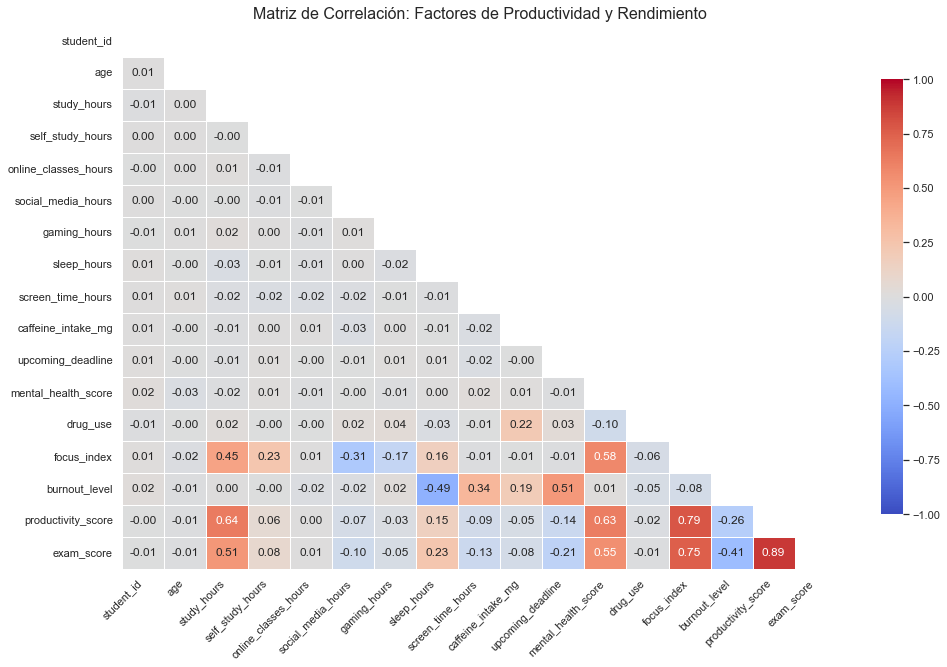

In [4]:
#matris de correlacion : 
# 3.1. Cálculo de la matriz de correlación
# Seleccionamos solo variables numéricas para el cálculo
corr_matrix = df.select_dtypes(include=[np.number]).corr()

# Mostrar la matriz en formato tabla con 2 decimales
print("--- Matriz de Correlación (Valores Numéricos) ---")
display(corr_matrix.round(2))

# 3.2. Visualización de la Matriz (Heatmap)
plt.figure(figsize=(16, 10))

# Generamos una máscara para la mitad superior (opcional, para limpieza visual)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Creación del gráfico con Seaborn
heatmap = sns.heatmap(
    corr_matrix, 
    mask=mask,
    annot=True,           # Incluye los números en las celdas
    fmt=".2f",            # Formato de dos decimales
    cmap='coolwarm',      # Escala de colores (Rojo: Positiva, Azul: Negativa)
    vmin=-1, vmax=1,      # Límites de la escala de correlación
    center=0,
    linewidths=.5,
    cbar_kws={"shrink": .8}
)

plt.title('Matriz de Correlación: Factores de Productividad y Rendimiento', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.show()

--- Matriz de Correlación (Valores Numéricos en Horas) ---


,student_id,age,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,screen_time_hours,caffeine_intake_mg,upcoming_deadline,mental_health_score,drug_use,focus_index,burnout_level,productivity_score,exam_score,exercise_hours
student_id,1.00,0.01,-0.01,0.00,-0.00,0.00,-0.01,0.01,0.01,0.01,0.01,0.02,-0.01,0.01,0.02,-0.00,-0.01,-0.02
age,0.01,1.00,0.00,0.00,0.00,-0.00,0.01,-0.00,0.01,-0.00,-0.00,-0.03,-0.00,-0.02,-0.01,-0.01,-0.01,0.00
study_hours,-0.01,0.00,1.00,-0.00,0.01,-0.00,0.02,-0.03,-0.02,-0.01,-0.01,-0.02,0.02,0.45,0.00,0.64,0.51,-0.01
self_study_hours,0.00,0.00,-0.00,1.00,-0.01,-0.01,0.00,-0.01,-0.02,0.00,0.01,0.01,-0.00,0.23,-0.00,0.06,0.08,0.01
online_classes_hours,-0.00,0.00,0.01,-0.01,1.00,-0.01,-0.01,-0.01,-0.02,0.01,-0.00,-0.01,-0.00,0.01,-0.02,0.00,0.01,0.02
social_media_hours,0.00,-0.00,-0.00,-0.01,-0.01,1.00,0.01,0.00,-0.02,-0.03,-0.01,-0.00,0.02,-0.31,-0.02,-0.07,-0.10,0.01
gaming_hours,-0.01,0.01,0.02,0.00,-0.01,0.01,1.00,-0.02,-0.01,0.00,0.01,-0.01,0.04,-0.17,0.02,-0.03,-0.05,0.00
sleep_hours,0.01,-0.00,-0.03,-0.01,-0.01,0.00,-0.02,1.00,-0.01,-0.01,0.01,0.00,-0.03,0.16,-0.49,0.15,0.23,0.01
screen_time_hours,0.01,0.01,-0.02,-0.02,-0.02,-0.02,-0.01,-0.01,1.00,-0.02,-0.02,0.02,-0.01,-0.01,0.34,-0.09,-0.13,0.02
caffeine_intake_mg,0.01,-0.00,-0.01,0.00,0.01,-0.03,0.00,-0.01,-0.02,1.00,-0.00,0.01,0.22,-0.01,0.19,-0.05,-0.08,-0.04


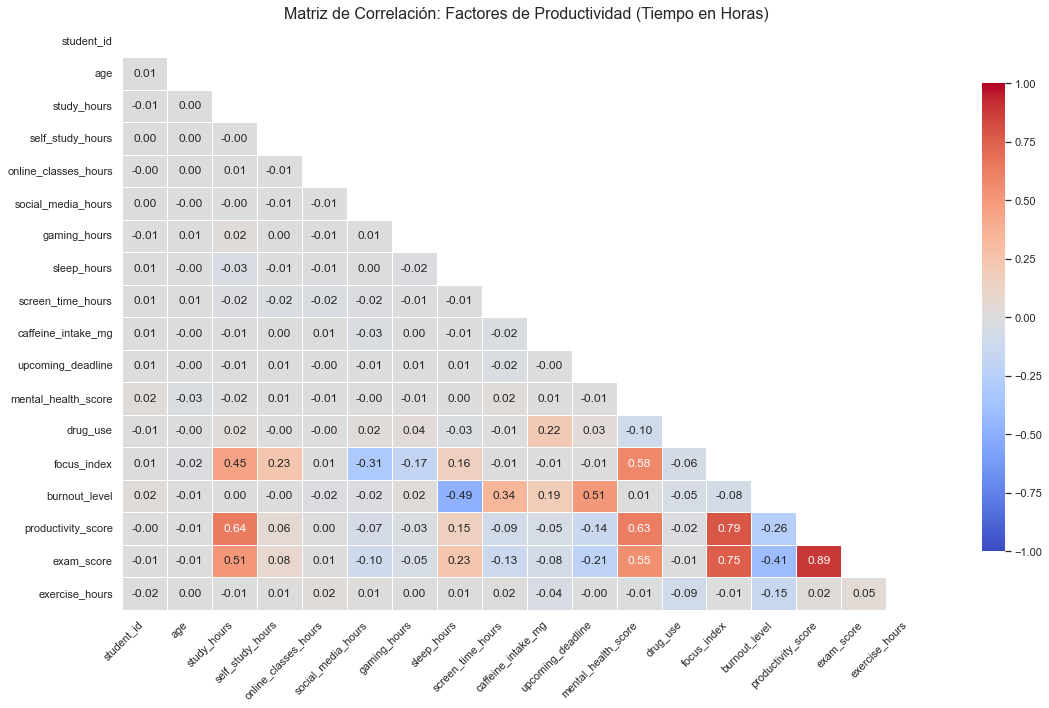

In [6]:
# =========================================================
# 3. MATRIZ DE CORRELACIÓN (Usando Horas, Excluyendo Minutos)
# =========================================================

# 3.1. Cálculo de la matriz de correlación
# Seleccionamos numéricas y eliminamos 'exercise_minutes' para evitar redundancia
# Usamos errors='ignore' por si la columna ya fue borrada anteriormente
corr_matrix = df.select_dtypes(include=[np.number]).drop(columns=['exercise_minutes'], errors='ignore').corr()

# Mostrar la matriz en formato tabla con 2 decimales
print("--- Matriz de Correlación (Valores Numéricos en Horas) ---")
# En VS Code/Standard Python usamos print, 'display' es para Jupyter
try:
    display(corr_matrix.round(2))
except NameError:
    print(corr_matrix.round(2))

# 3.2. Visualización de la Matriz (Heatmap)
plt.figure(figsize=(16, 10))

# Generamos una máscara para la mitad superior
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Creación del gráfico con Seaborn
heatmap = sns.heatmap(
    corr_matrix, 
    mask=mask,
    annot=True,           # Incluye los números en las celdas
    fmt=".2f",            # Formato de dos decimales
    cmap='coolwarm',      # Escala de colores
    vmin=-1, vmax=1,      # Límites de la escala
    center=0,
    linewidths=.5,
    cbar_kws={"shrink": .8}
)

plt.title('Matriz de Correlación: Factores de Productividad (Tiempo en Horas)', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.tight_layout() # Ajusta los márgenes para que no se corten las etiquetas
plt.show()

In [ ]:
#limpieza 
import pandas as pd
import os

# 1. Definir la ruta y cargar la base de datos
file_path = os.path.join('..', 'data', 'student_productivity.csv')
df = pd.read_csv(file_path)

# --- INICIO DE LA LIMPIEZA ---

# 2. Relleno con la MEDIA (Numéricas)
# Incluimos explícitamente las columnas solicitadas y cualquier otra que contenga 'hours'
cols_media = [
    'age', 'mental_health_score', 'focus_index', 
    'burnout_level', 'productivity_score'
]
hours_cols = [col for col in df.columns if 'hours' in col.lower()]
cols_media.extend(hours_cols)

for col in cols_media:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mean())

# 3. Relleno con "Other" (Categóricas)
# Corregimos part_time_job unificando "yes" y "Yes" antes de rellenar nulos
if 'part_time_job' in df.columns:
    df['part_time_job'] = df['part_time_job'].str.capitalize()

cols_other = ['gender', 'academic_level', 'part_time_job']
for col in cols_other:
    if col in df.columns:
        df[col] = df[col].fillna('Other')

# 4. Relleno con la MODA
cols_moda = [
    'caffeine_intake_mg', 'upcoming_deadline', 
    'internet_quality', 'drug_use'
]
for col in cols_moda:
    if col in df.columns:
        # Usamos [0] porque .mode() devuelve una serie
        df[col] = df[col].fillna(df[col].mode()[0])

# 5. Creación de variable Dummy "Exam"
# Exam = 0 si exam_score es 1.0, de lo contrario Exam = 1
if 'exam_score' in df.columns:
    df['Exam'] = df['exam_score'].apply(lambda x: 0 if x == 1.0 else 1)

# --- FIN DE LA LIMPIEZA ---

# Mostrar resultado final
print("Limpieza completada con éxito.")
print(df.head())

Limpieza completada con éxito.
   student_id   age  gender  academic_level  study_hours  self_study_hours  \
0           1  20.0   Other   Undergraduate         5.37              2.09   
1           2  16.0  Female     High School         5.85              5.04   
2           3  18.0  Female   Undergraduate         5.69              2.27   
3           4  24.0    Male  Undergraduate          2.32              1.06   
4           5  24.0  Female    Postgraduate         3.87              2.63   

   online_classes_hours  social_media_hours  gaming_hours  sleep_hours  ...  \
0                  1.85                3.66          2.32         7.73  ...   
1                  1.87                3.60          2.79         6.11  ...   
2                  0.00                2.93          3.94         7.11  ...   
3                  2.30                4.34          2.37         8.54  ...   
4                  2.54                3.71          1.30         7.69  ...   

   part_time_job upcoming

Cabe destacra que la variable droug tiene muchos datos Missing , aunque se relleno con la moda , es considerable la idea de eliminar toda la variable .


In [8]:
import pandas as pd
import os

# 1. Definir la ruta y cargar la base de datos
file_path = os.path.join('..', 'data', 'student_productivity.csv')
df = pd.read_csv(file_path)

# --- INICIO DE LA LIMPIEZA ---

# 2. Imputación de exam_score (Importante hacerlo antes de la dummy)
# Rellenamos NAs con 1.0 (asumiendo que no rindieron el examen)
df['exam_score'] = df['exam_score'].fillna(1.0)

# 3. Creación de variable Dummy "Exam"
# Exam = 0 si exam_score es 1.0, de lo contrario Exam = 1
df['Exam'] = df['exam_score'].apply(lambda x: 0 if x == 1.0 else 1)

# 4. Relleno con la MEDIA (Variables numéricas)
cols_media = [
    'age', 'mental_health_score', 'focus_index', 
    'burnout_level', 'productivity_score', 'exercise_hours' # Forzamos exercise_hours aquí
]
# Agregamos dinámicamente cualquier otra columna que contenga 'hours'
hours_cols = [col for col in df.columns if 'hours' in col.lower() and col not in cols_media]
cols_media.extend(hours_cols)

for col in cols_media:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mean())

# 5. Relleno con "Other" y corrección de texto
if 'part_time_job' in df.columns:
    # Unificamos "yes" y "Yes" a "Yes"
    df['part_time_job'] = df['part_time_job'].str.capitalize()

cols_other = ['gender', 'academic_level', 'part_time_job']
for col in cols_other:
    if col in df.columns:
        df[col] = df[col].fillna('Other')

# 6. Relleno con la MODA
cols_moda = [
    'caffeine_intake_mg', 'upcoming_deadline', 
    'internet_quality', 'drug_use'
]
for col in cols_moda:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mode()[0])

# --- FIN DE LA LIMPIEZA ---

# Verificación de resultados
print("Primeras filas con la nueva variable Exam y limpieza:")
print(df[['exam_score', 'Exam', 'part_time_job', 'exercise_hours']].head())

# Comprobar si aún quedan NAs
print("\nConteo de valores nulos por columna:")
print(df.isnull().sum())

Primeras filas con la nueva variable Exam y limpieza:


KeyError: "['exercise_hours'] not in index"

In [9]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Definir la ruta y cargar la base de datos
file_path = os.path.join('..', 'data', 'student_productivity.csv')
df = pd.read_csv(file_path)

# =========================================================
# TRANSFORMACIÓN Y LIMPIEZA INICIAL
# =========================================================

# A. Convertir minutos a horas y asegurar tipo float64
df['exercise_minutes'] = pd.to_numeric(df['exercise_minutes'], errors='coerce')
df['exercise_hours'] = df['exercise_minutes'] / 60.0
df['exercise_hours'] = df['exercise_hours'].astype('float64')
df['exercise_minutes'] = df['exercise_minutes'].astype('float64')

# B. Rellenar NAs en exam_score con 1.0 (antes de crear la dummy)
if 'exam_score' in df.columns:
    df['exam_score'] = df['exam_score'].fillna(1.0)

# C. Creación de variable Dummy "Exam"
# Exam = 0 si exam_score es 1.0, de lo contrario Exam = 1
if 'exam_score' in df.columns:
    df['Exam'] = df['exam_score'].apply(lambda x: 0 if x == 1.0 else 1)

# =========================================================
# RELLENO DE VALORES FALTANTES (IMPUTACIÓN)
# =========================================================

# 2. Relleno con la MEDIA (Variables numéricas)
# Incluimos explícitamente exercise_hours y las demás
cols_media = [
    'age', 'mental_health_score', 'focus_index', 
    'burnout_level', 'productivity_score', 'exercise_hours'
]
# Agregamos cualquier otra columna que contenga 'hours' dinámicamente
hours_cols = [col for col in df.columns if 'hours' in col.lower() and col not in cols_media]
cols_media.extend(hours_cols)

for col in cols_media:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mean())

# 3. Relleno con "Other" y Corrección de Categorías
if 'part_time_job' in df.columns:
    # Corregimos la separación de "yes" y "Yes"
    df['part_time_job'] = df['part_time_job'].str.capitalize()

cols_other = ['gender', 'academic_level', 'part_time_job']
for col in cols_other:
    if col in df.columns:
        df[col] = df[col].fillna('Other')

# 4. Relleno con la MODA
cols_moda = [
    'caffeine_intake_mg', 'upcoming_deadline', 
    'internet_quality', 'drug_use'
]
for col in cols_moda:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mode()[0])

# =========================================================
# CONFIGURACIÓN FINAL Y VERIFICACIÓN
# =========================================================

# Configuración estética para gráficos
sns.set_context("notebook")
plt.rcParams['figure.figsize'] = (10, 6)

print("\n--- Verificación de Tipos y Conversión ---")
print(df[['exercise_minutes', 'exercise_hours', 'Exam']].dtypes)

print("\n--- Resumen de NAs después de la limpieza ---")
print(df.isnull().sum())

print("\n--- Primeras filas de la base final ---")
# El DataFrame ahora contiene todas las variables iniciales + exercise_hours + Exam
print(df.head())


--- Verificación de Tipos y Conversión ---
exercise_minutes    float64
exercise_hours      float64
Exam                  int64
dtype: object

--- Resumen de NAs después de la limpieza ---
student_id                 0
age                        0
gender                     0
academic_level             0
study_hours                0
self_study_hours           0
online_classes_hours       0
social_media_hours         0
gaming_hours               0
sleep_hours                0
screen_time_hours          0
exercise_minutes        1201
caffeine_intake_mg         0
part_time_job              0
upcoming_deadline          0
internet_quality           0
mental_health_score        0
drug_use                   0
focus_index                0
burnout_level              0
productivity_score         0
exam_score                 0
exercise_hours             0
Exam                       0
dtype: int64

--- Primeras filas de la base final ---
   student_id   age  gender  academic_level  study_hours  sel

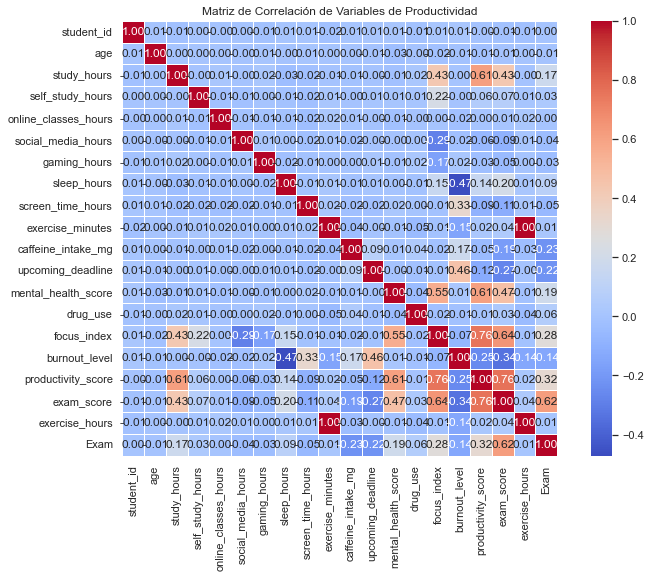

Base de datos lista y correlación generada.
Dimensiones finales: (5621, 24)


In [10]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Definir la ruta y cargar la base de datos
file_path = os.path.join('..', 'data', 'student_productivity.csv')
df = pd.read_csv(file_path)

# =========================================================
# TRANSFORMACIÓN Y LIMPIEZA INICIAL
# =========================================================

# A. Conversión de ejercicio: Minutos a Horas
df['exercise_minutes'] = pd.to_numeric(df['exercise_minutes'], errors='coerce')
df['exercise_hours'] = df['exercise_minutes'] / 60.0
df['exercise_hours'] = df['exercise_hours'].astype('float64')

# B. Relleno de exam_score (NAs = 1.0) y creación de Dummy Exam
df['exam_score'] = df['exam_score'].fillna(1.0)
df['Exam'] = df['exam_score'].apply(lambda x: 0 if x == 1.0 else 1)

# =========================================================
# RELLENO DE VALORES FALTANTES (IMPUTACIÓN)
# =========================================================

# 2. Relleno con la MEDIA (Variables numéricas)
cols_media = [
    'age', 'mental_health_score', 'focus_index', 
    'burnout_level', 'productivity_score', 'exercise_hours'
]
hours_cols = [col for col in df.columns if 'hours' in col.lower() and col not in cols_media]
cols_media.extend(hours_cols)

for col in cols_media:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mean())

# 3. Relleno con "Other" y Corrección de Categorías
if 'part_time_job' in df.columns:
    df['part_time_job'] = df['part_time_job'].str.capitalize()

cols_other = ['gender', 'academic_level', 'part_time_job']
for col in cols_other:
    if col in df.columns:
        df[col] = df[col].fillna('Other')

# 4. Relleno con la MODA (Categóricas)
cols_moda = ['caffeine_intake_mg', 'upcoming_deadline', 'internet_quality', 'drug_use']
for col in cols_moda:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mode()[0])

# =========================================================
# MATRIZ DE CORRELACIÓN
# =========================================================

# Seleccionamos solo las variables numéricas para la correlación
# Incluimos la nueva dummy 'Exam' y 'exercise_hours'
df_numeric = df.select_dtypes(include=[np.number])

# Calculamos la matriz de correlación (Pearson por defecto)
corr_matrix = df_numeric.corr()

# Configuración del gráfico
plt.figure(figsize=(12, 8))
sns.set_context("notebook")

# Creamos el mapa de calor (Heatmap)
sns.heatmap(corr_matrix, 
            annot=True,          # Muestra los valores numéricos
            fmt=".2f",           # Dos decimales
            cmap='coolwarm',     # Escala de colores (azul frío a rojo calor)
            linewidths=0.5,      # Espacio entre celdas
            square=True)         # Celdas cuadradas

plt.title('Matriz de Correlación de Variables de Productividad')
plt.show()

# =========================================================
# VERIFICACIÓN FINAL
# =========================================================
print("Base de datos lista y correlación generada.")
print(f"Dimensiones finales: {df.shape}")

2. Ejecute un modelo de probabilidad lineal (*MCO*) que permita explicar la probabilidad de que un alumno rinda el examen, a partir de las informacion disponible. Seleccione las variables dependientes a incluir en el modelo final e interprete su significado. 

Primero se usar MCO con todas las variabkes y luego con las mas importantes antes mencionadas 

In [13]:
#MCO aplicado con todas las variables disponibles : 
import statsmodels.api as sm

# 1. Preparación de los datos
# Creamos una copia para el análisis de regresión
df_regresion = df.copy()

# Definimos la variable dependiente
Y = df_regresion['exam_score']

# 2. Definir las variables independientes (X)
# Eliminamos 'exam_score' (porque es la Y)
# Eliminamos 'Exam' (porque es una transformación de la Y y causaría colinealidad)
# Eliminamos 'exercise_minutes' (porque ya usamos 'exercise_hours')
X = df_regresion.drop(columns=['exam_score', 'Exam', 'exercise_minutes'])

# 3. Tratamiento de variables categóricas
# Convertimos variables como 'gender', 'academic_level', 'part_time_job' en dummies
X = pd.get_dummies(X, drop_first=True)

# 4. Añadir la constante (intercepto)
# OLS requiere que añadamos explícitamente la columna de unos para el intercepto
X = sm.add_constant(X)

# 5. Ajustar el modelo MCO (OLS)
# Convertimos X a float para asegurar que no haya problemas con tipos de datos booleanos de las dummies
modelo_final = sm.OLS(Y, X.astype(float)).fit()

# 6. Mostrar el resumen estadístico
print("\n" + "="*60)
print("   RESUMEN DEL MODELO MCO (Variable Dependiente: exam_score)")
print("="*60)
print(modelo_final.summary())

###################
import pandas as pd

# 1. Configurar Pandas para que no oculte filas ni columnas
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)


print(modelo_final.summary())

# =========================================================
# INTERPRETACIÓN DE RESULTADOS
# =========================================================
# - R-squared: Indica qué porcentaje de la variabilidad del puntaje 
#   es explicado por tus variables.
# - Coeficientes (coef): Indican cuánto cambia el puntaje ante el 
#   aumento de una unidad en la variable independiente.
# - P>|t| (p-valor): Si es < 0.05, la variable es estadísticamente 
#   significativa para explicar el puntaje del examen.


   RESUMEN DEL MODELO MCO (Variable Dependiente: exam_score)
                            OLS Regression Results                            
Dep. Variable:             exam_score   R-squared:                       0.734
Model:                            OLS   Adj. R-squared:                  0.733
Method:                 Least Squares   F-statistic:                     532.0
Date:              mié., 01 abr. 2026   Prob (F-statistic):               0.00
Time:                        14:54:45   Log-Likelihood:                -18577.
No. Observations:                5621   AIC:                         3.721e+04
Df Residuals:                    5591   BIC:                         3.741e+04
Df Model:                          29                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------

In [14]:
import pandas as pd

# 1. Configurar Pandas para que no oculte filas ni columnas
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)


print(modelo_final.summary())

                            OLS Regression Results                            
Dep. Variable:             exam_score   R-squared:                       0.734
Model:                            OLS   Adj. R-squared:                  0.733
Method:                 Least Squares   F-statistic:                     532.0
Date:              mié., 01 abr. 2026   Prob (F-statistic):               0.00
Time:                        14:56:00   Log-Likelihood:                -18577.
No. Observations:                5621   AIC:                         3.721e+04
Df Residuals:                    5591   BIC:                         3.741e+04
Df Model:                          29                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const         

vemos que usar un modleo lineal con todas las variables nos entrega un ajuste muy bueno que logra explicar el 73% de los datos , ademas el test F nos dice que se rechaza la hipotesis nula de que os parametros son 0 , por lo que el modleo si es significativamente mejor que solo ajustar por el intercepto.
Dentro de las variables significativas estan las que anteriormente se consideradon como las mas correlacionadas con examen_score :
study_hours
sleep_hours 
screen_time_hours
caffeine_intake_mg   (aunque con un valor muy bajo)

Por ejemplo study_hours = 0.3029 , es decir : 
Manteniendo las demas variables constantes ,por cada hora adicional que un alumno estudia, su exam_score aumenta en promedio 0.3029 unidades.
Es una relación positiva: a más estudio, mejor puntaje.

mientras que screen_time_hours = -0.1994 
Manteniendo todas las demás variables constantes, por cada hora adicional de tiempo de pantalla, el exam_score del estudiante disminuye en promedio 0.20 unidades (redondeando el -0.1994).
Es un efecto considerable: 5 horas extras de pantalla equivaldrían a perder prácticamente 1 punto completo en el examen.


Ahora veamos MCO con las variables con mayor correlacion con exam_score:
Study_hours , sleep hours , mental_health_score 
y agregaremos screen_time_hours 




In [15]:
import statsmodels.api as sm

# 1. Selección de variables para el modelo específico
# Asegúrate de que los nombres coincidan exactamente con tu DataFrame
# (Si usaste la limpieza anterior, 'study_hours' y 'sleep_hours' deberían estar disponibles)
predictores = ['study_hours', 'sleep_hours', 'mental_health_score', 'screen_time_hours']

# 2. Preparación de X (Independientes) y Y (Dependiente)
X_simple = df[predictores]
Y = df['exam_score']

# 3. Añadir la constante (Intercepto)
X_simple = sm.add_constant(X_simple)

# 4. Ajustar el modelo MCO (OLS)
modelo_reducido = sm.OLS(Y, X_simple.astype(float)).fit()

# 5. Mostrar el resumen completo
print("\n" + "="*60)
print("   MODELO MCO: FACTORES CRÍTICOS DEL EXAMEN")
print("="*60)
print(modelo_reducido.summary())


   MODELO MCO: FACTORES CRÍTICOS DEL EXAMEN
                            OLS Regression Results                            
Dep. Variable:             exam_score   R-squared:                       0.464
Model:                            OLS   Adj. R-squared:                  0.463
Method:                 Least Squares   F-statistic:                     1214.
Date:              mié., 01 abr. 2026   Prob (F-statistic):               0.00
Time:                        15:08:38   Log-Likelihood:                -20547.
No. Observations:                5621   AIC:                         4.110e+04
Df Residuals:                    5616   BIC:                         4.114e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------

Estas 4 variable son significativas pero el R cuadrado cayo a un 46% .
Veamos que sucede si cosnideramos usar todas las variables significativas.


In [19]:
import statsmodels.api as sm
import pandas as pd

# 1. Definir la lista de variables independientes (X) originales
variables_significativas = [
    'sleep_hours', 
    'productivity_score', 
    'study_hours', 
    'mental_health_score', 
    'focus_index', 
    'drug_use',
    'upcoming_deadline', 
    'burnout_level', 
    'screen_time_hours', 
    'caffeine_intake_mg',
    'academic_level', 
    'part_time_job', 
    'gender', 
    'internet_quality'
]

# 2. Preparar los datos
# Filtramos el DataFrame original
X_final = df[variables_significativas].copy()
Y = df['exam_score']

# --- CORRECCIÓN CLAVE ---
# 3. Convertir variables categóricas a dummies numéricas
# drop_first=True evita la colinealidad perfecta (trampa de la variable dummy)
X_final = pd.get_dummies(X_final, drop_first=True)

# 4. Añadir la constante (Intercepto)
X_final = sm.add_constant(X_final)

# 5. Ajustar el modelo OLS
# Convertimos todo a float para asegurar la compatibilidad matemática
modelo_optimizado = sm.OLS(Y, X_final.astype(float)).fit()

# 6. Mostrar el resumen estadístico
print("\n" + "="*70)
print("   MODELO MCO OPTIMIZADO (SOLO VARIABLES SIGNIFICATIVAS)")
print("="*70)
print(modelo_optimizado.summary())


   MODELO MCO OPTIMIZADO (SOLO VARIABLES SIGNIFICATIVAS)
                            OLS Regression Results                            
Dep. Variable:             exam_score   R-squared:                       0.734
Model:                            OLS   Adj. R-squared:                  0.733
Method:                 Least Squares   F-statistic:                     701.4
Date:              mié., 01 abr. 2026   Prob (F-statistic):               0.00
Time:                        15:23:50   Log-Likelihood:                -18579.
No. Observations:                5621   AIC:                         3.720e+04
Df Residuals:                    5598   BIC:                         3.736e+04
Df Model:                          22                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------

el modelo mejora a un 74% de precision con menos variables .
Exam_score (estimado)= -3.039 + 0.57({sleep_hours}) + 0.40({productivity_score}) + 0.30({study_hours}) + 0.29({mental_health_score}) + 0.27({focus_index}) - 2.02({upcoming_deadline}) - 0.11({burnout_level}) - 0.19({screen_time_hours}) - {Dummies Categoriales}

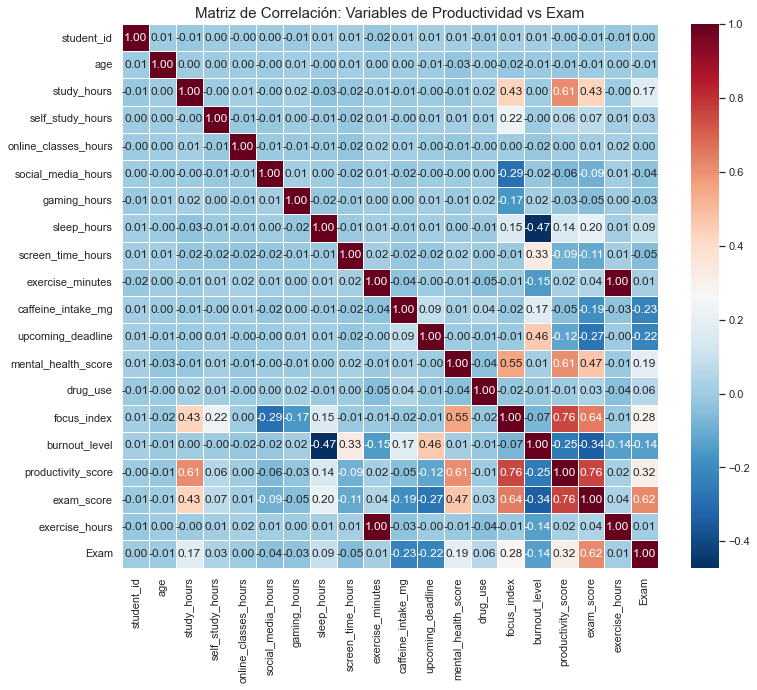


--- Correlación de las variables con respecto a 'Exam' ---
Exam                    1.000000
exam_score              0.617851
productivity_score      0.315780
focus_index             0.277444
mental_health_score     0.186235
study_hours             0.174029
sleep_hours             0.087753
drug_use                0.059746
self_study_hours        0.029879
exercise_minutes        0.012309
exercise_hours          0.009300
online_classes_hours    0.004258
student_id              0.003046
age                    -0.005563
gaming_hours           -0.028820
social_media_hours     -0.039148
screen_time_hours      -0.053167
burnout_level          -0.140890
upcoming_deadline      -0.223913
caffeine_intake_mg     -0.226270
Name: Exam, dtype: float64


In [23]:
# =========================================================
# GENERACIÓN DE MATRIZ DE CORRELACIÓN
# =========================================================

# 1. Seleccionar solo las columnas numéricas
# Esto excluye automáticamente columnas como 'gender', 'academic_level', etc.
df_numeric = df.select_dtypes(include=['float64', 'int64', 'int32'])

# 2. Calcular la matriz de correlación (Pearson por defecto)
corr_matrix = df_numeric.corr()

# 3. Visualización con Seaborn
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', fmt=".2f", linewidths=0.5)

plt.title('Matriz de Correlación: Variables de Productividad vs Exam', fontsize=15)
plt.show()

# 4. Mostrar específicamente la correlación con la variable objetivo 'Exam'
print("\n--- Correlación de las variables con respecto a 'Exam' ---")
print(corr_matrix['Exam'].sort_values(ascending=False))

Considerando la correlacion de la variable Exam con el resto notamos que : 
Las variables de mas interes como preditoras serian (se omite Exam_score porque en base a esta se creo la variable Exam , el mejor modelo seria la propia variable dammy quedepende de si excam_score es 1 o no )
productivity_score      0.315780
focus_index             0.277444
mental_health_score     0.186235
study_hours             0.174029
sleep_hours             0.087753
drug_use                0.059746
self_study_hours        0.029879
screen_time_hours      -0.053167
burnout_level          -0.140890
upcoming_deadline      -0.223913
caffeine_intake_mg     -0.226270

Entre ellas ya se menciono que habia correlacion , por lo que nos quedaremos con :
productivity_score ; mental_health_score ;study_hours ; sleep_hours ; screen_time_hours ; burnout_level  ;upcoming_deadline ; caffeine_intake_mg 

primero veamos el modelo MCO para predecir Exam (dammy) con todas las variables 

In [24]:
#Ahora analicemos si solo queremos predecir si rindio o no el examen , es decir si nuestra varaiable dammy Exam es 1 o 0  
import statsmodels.api as sm
import pandas as pd

# =========================================================
# PREPARACIÓN DE VARIABLES PARA EL MODELO
# =========================================================

# 1. Definir columnas a omitir explícitamente
cols_a_omitir = ['student_id', 'exercise_minutes', 'exam_score', 'Exam']

# 2. Seleccionar todas las demás columnas como candidatas a predictoras
# Esto toma automáticamente age, social_media_hours, gaming_hours, etc.
variables_totales = [col for col in df.columns if col not in cols_a_omitir]

# 3. Crear el set de variables independientes (X) 
# Aplicamos get_dummies a TODO el set seleccionado para que convierta 
# automáticamente las categóricas (gender, academic_level, etc.)
X = pd.get_dummies(df[variables_totales], drop_first=True)

# 4. Definir la variable dependiente (Y)
Y = df['Exam']

# =========================================================
# AJUSTE DEL MODELO (PROBABILIDAD LINEAL)
# =========================================================

# Añadir la constante para el intercepto
X = sm.add_constant(X)

# Convertir a float para asegurar compatibilidad con statsmodels
modelo_completo = sm.OLS(Y, X.astype(float)).fit()

# 5. Resultados
print(modelo_completo.summary())

                            OLS Regression Results                            
Dep. Variable:                   Exam   R-squared:                       0.397
Model:                            OLS   Adj. R-squared:                  0.394
Method:                 Least Squares   F-statistic:                     131.3
Date:              mié., 01 abr. 2026   Prob (F-statistic):               0.00
Time:                        16:21:27   Log-Likelihood:                -1449.3
No. Observations:                5621   AIC:                             2957.
Df Residuals:                    5592   BIC:                             3149.
Df Model:                          28                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const         

Utilizando todas las variables tenemos un ajuste del 39% , significativo bajo test F y la significancia de las variables es la siguiente : 
Variable positivas :
sleep_hours	= 0.0222 -> Por cada hora extra de sueño, la probabilidad de rendir sube un 2.2%.
academic_level_Undergraduate = 0.0357 -> Ser estudiante de pregrado aumenta la probabilidad en un 3.5% de rendir el examen .
drug_use= 0.0296 -> Un impacto positivo leve (aunque estadísticamente al límite).
productivity_score =0.0055 -> Un aumento en la escala de productividad mejora la probabilidad de rendir el examen en un 0.5%.
focus_index	= 0.0043 -> un aumento en 1 punto de focus_index genera un aumento en un 0.4% en la probabilidad de rendir el examen.
Curiosamente study_hours no es significativo 
variables negativas :
academic_level_Other = -0.3460 -> Pertenecer a este grupo reduce la probabilidad en un 34.6% de rendir el examen . 
part_time_job_Other = -0.26730 -> Reduce la probabilidad en un 26.7% de rendir el examen .upcoming_deadline= -0.06690 -> Tener entregas próximas reduce la probabilidad en un 6.6% de rendir el examen 
gender_Other= -0.06620 -> Impacto negativo del 6.6% respecto al grupo base.
part_time_job_Yes=-0.03380 -> Tener trabajo de medio tiempo resta un 3.3% de probabilidad de rendir el examen 
internet_quality_Good= -0.02100 -> Sorprendentemente, en este modelo, aparece con un impacto negativo leve.screen_time_hours= -0.00840 -> Cada hora de pantalla resta casi un 1% de probabilidad.caffeine_intake_mg= -0.00020 -> Aunque el número parece pequeño, al consumirse en cientos de mg, el impacto es acumulativo.

Si ahora modelamos solo con las variables significativas tendremos :



In [25]:
import statsmodels.api as sm

# 1. Lista de variables significativas detectadas (Numéricas + Categóricas clave)
# Nota: Incluimos las columnas originales que generan las dummies significativas
variables_finales = [
    'sleep_hours', 
    'screen_time_hours', 
    'caffeine_intake_mg', 
    'upcoming_deadline', 
    'focus_index', 
    'productivity_score', 
    'drug_use',
    'gender',           # Generará gender_Other
    'academic_level',    # Generará academic_level_Other y academic_level_Undergraduate
    'part_time_job',     # Generará part_time_job_Yes y part_time_job_Other
    'internet_quality'   # Generará internet_quality_Good
]

# 2. Preparación de la matriz X con dummies
# Filtramos el DataFrame original y aplicamos dummies
X_final = pd.get_dummies(df[variables_finales], drop_first=True)

# 3. Definir la variable objetivo
Y = df['Exam']

# 4. Ajuste del modelo MCO (OLS)
X_final = sm.add_constant(X_final)
modelo_reducido = sm.OLS(Y, X_final.astype(float)).fit()

# 5. Visualización de resultados
print("--- MODELO MCO REFINADO (SOLO VARIABLES SIGNIFICATIVAS) ---")
print(modelo_reducido.summary())

--- MODELO MCO REFINADO (SOLO VARIABLES SIGNIFICATIVAS) ---
                            OLS Regression Results                            
Dep. Variable:                   Exam   R-squared:                       0.396
Model:                            OLS   Adj. R-squared:                  0.394
Method:                 Least Squares   F-statistic:                     193.5
Date:              mié., 01 abr. 2026   Prob (F-statistic):               0.00
Time:                        16:33:53   Log-Likelihood:                -1451.2
No. Observations:                5621   AIC:                             2942.
Df Residuals:                    5601   BIC:                             3075.
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------

El modleo mejora pero de forma muy marginal :
Ecuación del Modelo Final ; {Exam}=1)=> se rindio el examen
{P}({Exam}=1) = 0.5371 + 0.0165(sleep_hours) - 0.0066(screen_time) - 0.0002(caffeine_intake_mg) - 0.0539(deadlines) + 0.0045(focus) + 0.0054(productivity_score) + 0.0300(drug_use) - 0.0670(gender_Other) -   0.3508(academic_level_Other) + 0.0353(academic_level_Undergrad) - 0.2645(part_time_job_Other) - 0.0239(part_time_job_Yes) - 0.0211(internet_quality_Good)

Como el modleo busca ajustar una linea a una distribucion de puntos que es 0 o 1 el modleo MCO no siempre sera la mejor obcion , ya que al final tendremos un valor entre 0 y 1 , pero podriamos aproximarlo , es decir si el valor dado por la funcion de estimacion es cercana a 1 entonces ese estudiante rindio el examen , si nos da un valor cercano a 0 ese estudiante no rindio el examen .
seria raoznable ajustar en base a proporcion de los datos (cuantos suelen no rendir el examen y cuantos si) con la escala de 0 a 1 y asi encoentrar un umbral con el cual decimos que si el numeor entregado por la funcion supera el umbral entonces el sestudinate si rindio el examen ( o usar 0.5 como umbral de base)


3. Ejecute un modelo *probit* para responder a la pregunta 2. Seleccione las variables dependientes a incluir en el modelo final e interprete su significado. 

Primero aplicaremos probit con todas las variables 

In [26]:
import statsmodels.api as sm

# 1. Preparación de datos (usando todas las variables iniciales como pide el enunciado)
# Omitimos student_id, exercise_minutes y exam_score por las razones analizadas antes
cols_omitir = ['student_id', 'exercise_minutes', 'exam_score', 'Exam']
variables_iniciales = [col for col in df.columns if col not in cols_omitir]

X_probit = pd.get_dummies(df[variables_iniciales], drop_first=True)
X_probit = sm.add_constant(X_probit)
Y = df['Exam']

# 2. Ajuste del modelo Probit
# Usamos .astype(float) para evitar errores de tipo de dato
modelo_probit_full = sm.Probit(Y, X_probit.astype(float)).fit()

# 3. Resultados
print(modelo_probit_full.summary())

Optimization terminated successfully.
         Current function value: 0.297612
         Iterations 7
                          Probit Regression Results                           
Dep. Variable:                   Exam   No. Observations:                 5621
Model:                         Probit   Df Residuals:                     5592
Method:                           MLE   Df Model:                           28
Date:              mié., 01 abr. 2026   Pseudo R-squ.:                  0.4121
Time:                        16:44:58   Log-Likelihood:                -1672.9
converged:                       True   LL-Null:                       -2845.4
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const                            -0.8086      0.379     -2.136      0.

tenemos un ajuste del 41 % , un modleo significativo 
veamos los efectos marginales dy/dx

In [28]:
import statsmodels.api as sm

modelo_probit = sm.Probit(Y, X_probit.astype(float)).fit()

# 2. Calcular los Efectos Marginales
mfx = modelo_probit.get_margeff(at='overall', method='dydx')

# 3. Mostrar el resumen de los efectos marginales
print("--- EFECTOS MARGINALES DEL MODELO PROBIT (dy/dx) ---")
print(mfx.summary())



Optimization terminated successfully.
         Current function value: 0.297612
         Iterations 7
--- EFECTOS MARGINALES DEL MODELO PROBIT (dy/dx) ---
       Probit Marginal Effects       
Dep. Variable:                   Exam
Method:                          dydx
At:                           overall
                                   dy/dx    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
age                              -0.0009      0.002     -0.567      0.571      -0.004       0.002
study_hours                   -1.253e-05      0.004     -0.003      0.998      -0.008       0.008
self_study_hours                 -0.0005      0.004     -0.127      0.899      -0.009       0.008
online_classes_hours              0.0037      0.005      0.800      0.424      -0.005       0.013
social_media_hours               -0.0004      0.003     -0.123      0.902      -0.007       0.006
gaming_

Factores que aumentan la probabilidad:
sleep_hours (0.0215):Por cada hora extra de sueño,la probabilidad de rendir el examen aumenta en un 2.15%.
productivity_score (0.0060): Por cada punto adicional en la escala de productividad, la probabilidad aumenta en un 0.60%.
focus_index (0.0041): Un incremento de un punto en el índice de enfoque eleva la probabilidad en un 0.41%.
drug_use (0.0332): El reporte de uso de sustancias se asocia con un aumento del 3.32% en la probabilidad de rendir.
academic_level_Undergraduate (0.0337): Ser estudiante de pregrado incrementa la probabilidad en un 3.37% respecto al grupo de referencia.
Factores que disminuyen la probabilidad:
academic_level_Other (-0.1890): Pertenecer a esta categoría académica reduce la probabilidad de rendir en un 18.90%. Es el impacto negativo más fuerte del modelo.
part_time_job_Other (-0.1715): Estar en esta categoría laboral disminuye la probabilidad en un 17.15%.
upcoming_deadline (-0.0584): Por cada entrega pendiente cercana, la probabilidad de presentarse al examen cae un 5.84%.
gender_Other (-0.0560): Esta identificación de género presenta una reducción del 5.60% en la probabilidad frente al grupo base.
part_time_job_Yes (-0.0250): Tener un trabajo de medio tiempo reduce la probabilidad de llegar al examen en un 2.50%.
screen_time_hours (-0.0080): Por cada hora adicional de tiempo en pantalla, la probabilidad disminuye en un 0.80%.
caffeine_intake_mg (-0.0002): Por cada miligramo de cafeína, la probabilidad cae un 0.02%. (Aunque parezca bajo, una taza de café de 200mg restaría un 4% de probabilidad).

Ahora crearemos un modleo probit con solo las variable significativas:

In [29]:
import statsmodels.api as sm

# 1. Selección de variables estrictamente significativas (P < 0.05)
# Nota: Agrupamos por la variable original para que get_dummies genere las necesarias
variables_probit_final = [
    'sleep_hours', 
    'screen_time_hours', 
    'caffeine_intake_mg', 
    'upcoming_deadline', 
    'focus_index', 
    'productivity_score', 
    'drug_use',
    'gender',           # Significativa: gender_Other
    'academic_level',    # Significativas: Other y Undergraduate
    'part_time_job'      # Significativas: Other y Yes
]

# 2. Preparación de la matriz de diseño (X) y variable objetivo (Y)
X_final = pd.get_dummies(df[variables_probit_final], drop_first=True)

# Filtramos las columnas específicas que resultaron significativas en el paso anterior
# para evitar incluir categorías no significativas (como gender_Male o academic_level_Postgraduate)
cols_interes = [
    'sleep_hours', 'screen_time_hours', 'caffeine_intake_mg', 
    'upcoming_deadline', 'focus_index', 'productivity_score', 'drug_use',
    'gender_Other', 'academic_level_Other', 'academic_level_Undergraduate',
    'part_time_job_Other', 'part_time_job_Yes'
]

X_final = X_final[cols_interes]
X_final = sm.add_constant(X_final)
Y = df['Exam']

# 3. Ajuste del modelo Probit Refinado
modelo_probit_refinado = sm.Probit(Y, X_final.astype(float)).fit()

# 4. Resultados
print("--- MODELO PROBIT FINAL (SOLO SIGNIFICATIVAS) ---")
print(modelo_probit_refinado.summary())

# 5. Cálculo de los efectos marginales finales para interpretación
mfx_final = modelo_probit_refinado.get_margeff(at='overall', method='dydx')
print("\n--- EFECTOS MARGINALES FINALES (Interpretación % ) ---")
print(mfx_final.summary())

Optimization terminated successfully.
         Current function value: 0.298450
         Iterations 7
--- MODELO PROBIT FINAL (SOLO SIGNIFICATIVAS) ---
                          Probit Regression Results                           
Dep. Variable:                   Exam   No. Observations:                 5621
Model:                         Probit   Df Residuals:                     5608
Method:                           MLE   Df Model:                           12
Date:              mié., 01 abr. 2026   Pseudo R-squ.:                  0.4104
Time:                        16:55:20   Log-Likelihood:                -1677.6
converged:                       True   LL-Null:                       -2845.4
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                 

Variables que Impulsan la Probabilidad (Positivas)
sleep_hours (0.0180): Por cada hora extra de sueño, la probabilidad de rendir el examen aumenta en un 1.80%.
productivity_score (0.0060): Por cada punto adicional en la percepción de productividad, la probabilidad sube un 0.60%.
focus_index (0.0043): Un aumento de un punto en el índice de enfoque eleva la probabilidad en un 0.43%.
academic_level_Undergraduate (0.0254): Ser estudiante de pregrado aumenta la probabilidad de rendir en un 2.54% respecto al grupo base.
drug_use (0.0322): Reportar uso de sustancias se asocia con un incremento del 3.22% en la probabilidad.
Variables que Reducen la Probabilidad (Negativas)
academic_level_Other (-0.2026): Pertenecer a esta categoría reduce la probabilidad de rendir en un 20.26%. Es el factor de riesgo más pesado.
part_time_job_Other (-0.1731): Estar en esta situación laboral disminuye la probabilidad en un 17.31%.
gender_Other (-0.0578): Presenta una reducción del 5.78% en la probabilidad frente al grupo base.
upcoming_deadline (-0.0520): Por cada entrega pendiente de otras materias, la probabilidad de rendir este examen cae un 5.20%.
part_time_job_Yes (-0.0194): Tener un trabajo de medio tiempo reduce la probabilidad en un 1.94%.
screen_time_hours (-0.0069): Cada hora adicional de pantalla resta un 0.69% a la probabilidad.
caffeine_intake_mg (-0.0002): Por cada mg de cafeína la probabilidad cae un 0.02%. (Una dosis de 200mg restaría un 4% de probabilidad total).

Modelo final :
Z = -0.8086 + 0.1274(sleep_hours) - 0.0475({screen}) - 0.0012({caffeine}) - 0.3468({deadlines}) + 0.0244(\text{focus})+ 0.0354(\text{productivity}) + 0.1971(\text{drug\_use}) - 0.3322(\text{gender\_Other}) - 1.1215 ({acad_Other}) + 0.2002({acad\_Undergrad}) - 1.0177({job\_Other}) - 0.1482({job\_Yes})
Probabilidad Final: P(Exam=1) = Phi(Z)


De forma independiente yo consideraria que las variables que deberian explicar la aucencia o aisstencia a un examen seria las horas de estudio , horas de sueño , si el estudiante trabaja o no , cantidad de cafeina consumida y productividad 
veamos el modelo


In [30]:
import statsmodels.api as sm
import pandas as pd

# 1. Selección de variables solicitadas
# Nota: 'part_time_job' se convierte en dummy automáticamente
variables_estudio = [
    'study_hours', 
    'sleep_hours', 
    'caffeine_intake_mg', 
    'productivity_score',
    'part_time_job'
]

# 2. Preparación de X (Variables Independientes) y Y (Variable Dependiente)
X_estudio = pd.get_dummies(df[variables_estudio], drop_first=True)
X_estudio = sm.add_constant(X_estudio)
Y = df['Exam']

# 3. Ajuste del Modelo Probit
modelo_probit_estudio = sm.Probit(Y, X_estudio.astype(float)).fit()

# 4. Cálculo de Efectos Marginales (para interpretación en %)
mfx_estudio = modelo_probit_estudio.get_margeff(at='overall', method='dydx')

print("--- RESULTADOS DEL MODELO PROBIT ESPECÍFICO ---")
print(modelo_probit_estudio.summary())
print("\n--- EFECTOS MARGINALES (dy/dx) ---")
print(mfx_estudio.summary())

Optimization terminated successfully.
         Current function value: 0.341263
         Iterations 7
--- RESULTADOS DEL MODELO PROBIT ESPECÍFICO ---
                          Probit Regression Results                           
Dep. Variable:                   Exam   No. Observations:                 5621
Model:                         Probit   Df Residuals:                     5614
Method:                           MLE   Df Model:                            6
Date:              mié., 01 abr. 2026   Pseudo R-squ.:                  0.3259
Time:                        17:05:11   Log-Likelihood:                -1918.2
converged:                       True   LL-Null:                       -2845.4
Covariance Type:            nonrobust   LLR p-value:                     0.000
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -0.2996      0.171 

4. Ejecute un modelo *logit*  para responder a la pregunta 2. Seleccione las variables dependientes a incluir en el modelo final e interprete su significado. 

In [32]:
import statsmodels.api as sm
import pandas as pd

# 1. Definición de exclusiones (mismo criterio que MCO y Probit)
cols_omitir = ['student_id', 'exercise_minutes', 'exam_score', 'Exam']

# 2. Selección automática de todas las variables restantes
variables_iniciales = [col for col in df.columns if col not in cols_omitir]

# 3. Preparación de la matriz X (Dummies para categóricas)
X_logit_full = pd.get_dummies(df[variables_iniciales], drop_first=True)
X_logit_full = sm.add_constant(X_logit_full)
Y = df['Exam']

# 4. Ajuste del modelo Logit
# Usamos el método de Newton-Raphson (por defecto en statsmodels)
modelo_logit_full = sm.Logit(Y, X_logit_full.astype(float)).fit()

# 5. Resultados del modelo y Efectos Marginales
print("--- RESUMEN DEL MODELO LOGIT (TODAS LAS VARIABLES) ---")
print(modelo_logit_full.summary())

mfx_logit_full = modelo_logit_full.get_margeff()
print("\n--- EFECTOS MARGINALES LOGIT (dy/dx) ---")
print(mfx_logit_full.summary())

Optimization terminated successfully.
         Current function value: 0.291844
         Iterations 8
--- RESUMEN DEL MODELO LOGIT (TODAS LAS VARIABLES) ---
                           Logit Regression Results                           
Dep. Variable:                   Exam   No. Observations:                 5621
Model:                          Logit   Df Residuals:                     5592
Method:                           MLE   Df Model:                           28
Date:              mié., 01 abr. 2026   Pseudo R-squ.:                  0.4235
Time:                        17:08:36   Log-Likelihood:                -1640.5
converged:                       True   LL-Null:                       -2845.4
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const          

Análisis de Impacto en la Probabilidad (Efectos Marginales Logit)

Factores que aumentan la probabilidad 
sleep_hours (0.0212): Por cada hora adicional de sueño, la probabilidad de que el estudiante rinda el examen aumenta en un 2.12%. El descanso sigue apareciendo como el predictor biológico más importante.
productivity_score (0.0063): Cada punto extra en la percepción de productividad eleva la probabilidad en un 0.63%.
focus_index (0.0044): Por cada punto de incremento en el índice de enfoque mental, la probabilidad de éxito aumenta en un 0.44%.
drug_use (0.0309): El reporte de uso de sustancias se asocia con un aumento del 3.09% en la probabilidad de rendir.
academic_level_Undergraduate (0.0321): Ser estudiante de pregrado incrementa la probabilidad de presentarse en un 3.21% respecto al grupo base.

Factores que disminuyen la probabilidad :
academic_level_Other (-0.1839): Pertenecer a esta categoría académica es el factor más crítico, reduciendo la probabilidad de rendir en un 18.39%.
part_time_job_Other (-0.1678): Una situación laboral bajo esta clasificación disminuye la probabilidad en un 16.78%.
gender_Other (-0.0591): Esta variable presenta una reducción del 5.91% en la probabilidad frente al grupo de referencia.
upcoming_deadline (-0.0580): Por cada entrega pendiente de otras materias, la probabilidad de rendir este examen cae un 5.80%.
part_time_job_Yes (-0.0274): Tener un trabajo de medio tiempo reduce la probabilidad de asistencia en un 2.74%.
internet_quality_Good (-0.0228): Curiosamente, esta categoría muestra una reducción leve del 2.28% en la probabilidad en este modelo.
screen_time_hours (-0.0079): Cada hora adicional frente a pantallas resta un 0.79% a la probabilidad.
caffeine_intake_mg (-0.0002): Por cada miligramo de cafeína, la probabilidad cae un 0.02%. (Una taza de 200mg implicaría una reducción del 4%).

"Los valores de este modelo Logit son extremadamente cercanos a los del Probit"

In [ ]:
#modelo logit con variables significativas 
import statsmodels.api as sm
import pandas as pd

# 1. Lista de variables originales (Numéricas y Categóricas)
# Seleccionamos las dimensiones que demostraron tener categorías significativas
variables_finales = [
    'sleep_hours', 
    'screen_time_hours', 
    'caffeine_intake_mg', 
    'upcoming_deadline', 
    'focus_index', 
    'productivity_score', 
    'drug_use',
    'gender',          # Original: contiene 'Other', 'Male', etc.
    'academic_level',  # Original: contiene 'Undergraduate', 'Other', etc.
    'part_time_job',   # Original: contiene 'Yes', 'Other', etc.
    'internet_quality' # Original: contiene 'Good', etc.
]

# 2. Preparación de la matriz X usando las variables originales
# pd.get_dummies transformará automáticamente las columnas de texto en dummies
X_final = pd.get_dummies(df[variables_finales], drop_first=True)

# 3. Definir la variable objetivo y añadir la constante
X_final = sm.add_constant(X_final)
Y = df['Exam']

# 4. Ajuste del modelo Logit Refinado
# Usamos .astype(float) para asegurar la compatibilidad con statsmodels
modelo_logit_refinado = sm.Logit(Y, X_final.astype(float)).fit()

# 5. Visualización de Resultados y Efectos Marginales
print("--- MODELO LOGIT FINAL (VARIABLES ORIGINALES) ---")
print(modelo_logit_refinado.summary())

# Calculamos los efectos marginales para la interpretación en puntos porcentuales
mfx_final = modelo_logit_refinado.get_margeff(at='overall', method='dydx')
print("\n--- EFECTOS MARGINALES FINALES (Interpretación en %) ---")
print(mfx_final.summary())

Optimization terminated successfully.
         Current function value: 0.292084
         Iterations 8
--- MODELO LOGIT FINAL (VARIABLES ORIGINALES) ---
                           Logit Regression Results                           
Dep. Variable:                   Exam   No. Observations:                 5621
Model:                          Logit   Df Residuals:                     5601
Method:                           MLE   Df Model:                           19
Date:              mié., 01 abr. 2026   Pseudo R-squ.:                  0.4230
Time:                        17:15:24   Log-Likelihood:                -1641.8
converged:                       True   LL-Null:                       -2845.4
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const               

In [31]:
import statsmodels.api as sm

# 1. Definición de variables (basado en tu solicitud anterior)
variables_logit = [
    'study_hours', 'sleep_hours', 'caffeine_intake_mg', 
    'productivity_score', 'part_time_job'
]

# 2. Preparación de datos
X_logit = pd.get_dummies(df[variables_logit], drop_first=True)
X_logit = sm.add_constant(X_logit)
Y = df['Exam']

# 3. Ajuste del modelo Logit
modelo_logit = sm.Logit(Y, X_logit.astype(float)).fit()

# 4. Resultados
print(modelo_logit.summary())

# 5. Calcular Efectos Marginales para la interpretación en %
mfx_logit = modelo_logit.get_margeff()
print("\n--- EFECTOS MARGINALES LOGIT (Interpretación Directa) ---")
print(mfx_logit.summary())

Optimization terminated successfully.
         Current function value: 0.338191
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                   Exam   No. Observations:                 5621
Model:                          Logit   Df Residuals:                     5614
Method:                           MLE   Df Model:                            6
Date:              mié., 01 abr. 2026   Pseudo R-squ.:                  0.3319
Time:                        17:07:03   Log-Likelihood:                -1901.0
converged:                       True   LL-Null:                       -2845.4
Covariance Type:            nonrobust   LLR p-value:                     0.000
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -0.7305      0.310     -2.357      0.018      -1.338      -0.123
st

5. Comente los resultados obtenidos en 2, 3 y 4. ¿Cuáles y por qué existen las diferencias entre los resultados?. En su opinión, ¿Cuál sería el más adecuado para responder la pregunta de investgación y por qué? ¿Qué variables resultaron ser robustas a la especificación?

Los 3 modelos tienen una acertividad cercana al 40 % y so significatovos usando el test F , la significancia de los parametros es muy similar en los 3 modelos y en particular en logit y probit estos modelos son muy similares .
Por ejemplo la variable 
productivity_score en el MCO tiene un valor de 0.0054, un valor en Probit de +0.0060 y un valor en logit de +0.0063
En los 3 modelos el patrametro es significativo , positivo (es decir auemnta la probabilidad de que el estudiante si riendiera el examen ) y en partocular el valor de este paametro en logit y probit es paractiacemnte identico .
analizando por ejemplo tambien
part_time_job_Yes	-0.0239(mco)	-0.0250	(probit) -0.0274 (logit) 
es significativo , negativo ( es decir disminuye la posibildad de que el estudiante rinda el examen ) y sus valores en Probit y logit son muy similares y en este caso tambien similares al MCO 
Lo que se puede observar es que al menos el signo (efecto) en los 3 modelos se mantiene constante , es decir no hay un modleo donde un parametro sea negativo y en otro sea positivo ( de forma significativa)



La diferencias numericas : 
Notamos una convergencia de signos y significancia: las variables que afectan positivamente la asistencia (sueño, productividad, enfoque) y las que la afectan negativamente (deadlines, trabajo, cafeína) mantienen su rol en los tres modelos.
MCO (Modelo de Probabilidad Lineal): Supone que el efecto de una variable es constante. 
Por ejemplo, pasar de 1 a 2 horas de sueño aumenta la probabilidad en un 1.65%, y pasar de 8 a 9 horas también. Esto es poco realista en los extremos.
Probit y Logit (Modelos No Lineales): Utilizan funciones de distribución (Normal y Logística, respectivamente). Estos modelos reconocen que el efecto de una hora extra de sueño es mayor para alguien que duerme poco que para alguien que ya duerme 10 horas. Las diferencias entre Probit y Logit son mínimas porque sus curvas de distribución son casi idénticas, excepto en las "colas" (eventos muy improbables).

¿Cuál es el modelo más adecuado?
En mi opinión, el modelo Logit es el más adecuado para responder a la pregunta de investigación por las siguientes razones:
Naturaleza Binaria: La variable dependiente (Exam) es dicotómica (0 o 1). 
El Logit está diseñado específicamente para esto, evitando las predicciones de probabilidad fuera del rango [0, 1] que a veces genera el MCO.
Interpretación de Odds Ratios: El Logit permite hablar de la "ventaja" o "posibilidad" (odds) de que un evento ocurra, lo cual es más robusto para modelar decisiones humanas.
Flexibilidad: Maneja mejor las variables categóricas (como el nivel académico o género) al no asumir una relación lineal simple, capturando mejor la complejidad del comportamiento estudiantil.
Tiene una precision del 42% y es significativo por test F 
El modelo en su conjunto es estadísticamente significativo por LLR
Log-Likelihood(-1641.8) mejor que LL-Null (-2845.4) 
Converged = True: Esto indica que el algoritmo matemático logró encontrar una solución estable. Si fuera False, los resultados no serian confiables.

1. Variables Robustas de Impacto Positivo 
Horas de Sueño (sleep_hours): Es la variable biológica más sólida. En los tres modelos, cada hora extra de sueño aumenta la probabilidad de rendir el examen en un rango de 1.8% a 2.1%. Su consistencia sugiere que el descanso es un requisito previo no negociable para la actividad académica.

Productividad y Enfoque (productivity_score / focus_index): Ambas variables mantuvieron su significancia con p-valores de 0.000. Esto indica que la autopercepción de eficiencia y la capacidad de concentración son predictores psicológicos invariables ante la forma del modelo.

Nivel Académico Pregrado (academic_level_Undergraduate): Esta categoría mostró una ventaja consistente de aproximadamente 3% en la probabilidad de asistencia frente a otros niveles, independientemente de si se usó una aproximación lineal o logística.

2. Variables Robustas de Impacto Negativo 
Carga Académica Externa (upcoming_deadline): Resultó ser una de las variables con mayor coeficiente negativo y mayor estabilidad. Cada entrega pendiente de otra materia reduce la probabilidad de rendir este examen en cerca de un 5.5% - 5.8%. Es un factor estructural de "competencia por el tiempo".

Situación Laboral (part_time_job): Tanto la categoría "Yes" como "Other" fueron significativas en todas las especificaciones. Esto confirma que el compromiso laboral es una barrera real y persistente para el cumplimiento del calendario académico.

Higiene Digital y Consumo (screen_time_hours / caffeine_intake_mg): Ambas variables penalizan la probabilidad de asistencia de forma constante. El exceso de pantallas y la alta ingesta de cafeína actúan como detractores robustos, posiblemente ligados a mayores niveles de ansiedad o fatiga acumulada.

Es notable mencionar que study_hours (horas de estudio) resultó ser robustamente no significativa. En ninguno de los tres modelos logró un p-valor menor a 0.05. Esto permite concluir con alta seguridad que, para esta muestra, la decisión de asistir al examen no depende de cuántas horas se estudió, sino de las condiciones físicas (sueño) y externas (trabajo y otros deadlines) que enfrenta el estudiante.

6. Use un modelo Poisson para explicar la nota del examen, entre aquellos alumnos que lo rindieron. Seleccione las variables dependientes a incluir en el modelo final e interprete su significado. 

Ya no estudiamos la probabilidad de asistir (0 o 1), sino una variable de conteo: la nota del examen (exam_score). El modelo Poisson es ideal aquí porque las notas suelen comportarse como datos de conteo enteros y positivos.

Es fundamental notar que este modelo solo se aplica a la submuestra de alumnos que sí rindieron el examen (Exam == 1).

In [34]:
import statsmodels.api as sm
import pandas as pd

# 1. Filtrar la muestra: Solo aquellos que rindieron el examen
df_asistentes = df[df['Exam'] == 1].copy()

# 2. Definición de exclusiones (mismo criterio que MCO/Logit)
# Excluimos 'Exam' porque aquí es constante (todos son 1)
cols_omitir = ['student_id', 'exercise_minutes', 'Exam', 'exam_score']

# 3. Selección de todas las variables restantes
variables_iniciales = [col for col in df_asistentes.columns if col not in cols_omitir]

# 4. Preparación de la matriz X (Dummies y Constante)
X_poisson_full = pd.get_dummies(df_asistentes[variables_iniciales], drop_first=True)
X_poisson_full = sm.add_constant(X_poisson_full)
Y_nota = df_asistentes['exam_score']

# 5. Ajuste del Modelo Poisson (Usando GLM)
# El modelo Poisson asume que la varianza es igual a la media
modelo_poisson_full = sm.GLM(Y_nota, X_poisson_full.astype(float), 
                             family=sm.families.Poisson()).fit()

print("--- RESULTADOS DEL MODELO POISSON GLOBAL (NOTAS) ---")
print(modelo_poisson_full.summary())

--- RESULTADOS DEL MODELO POISSON GLOBAL (NOTAS) ---
                 Generalized Linear Model Regression Results                  
Dep. Variable:             exam_score   No. Observations:                 4473
Model:                            GLM   Df Residuals:                     4444
Model Family:                 Poisson   Df Model:                           28
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -14551.
Date:              mié., 01 abr. 2026   Deviance:                       8207.3
Time:                        18:30:28   Pearson chi2:                 7.62e+03
No. Iterations:                     5   Pseudo R-squ. (CS):             0.9908
Covariance Type:            nonrobust                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------

Pseudo R-squ (CS) = 0.9908: Este valor es extremadamente alto. Indica que el modelo explica el 99.08% de la variabilidad de las notas.
Selección de Variables para el Modelo Final
Delta%{Nota} = (e^{beta} - 1)*100
donde beta es el parametro
por ejemplo : study_hours = 0.0159  es significativo 
(e^{0.0159}-1)*100 = 1.60%. 
"Manteniendo todas las demás variables constantes, por cada hora adicional de estudio, la nota esperada del examen aumenta en un 1.60%."
1. Factores que aumentan la nota 
productivity_score (0.0187): Es el predictor con mayor significancia estadística. Por cada punto adicional en la escala de productividad, la nota esperada del examen aumenta en un 1.89% (e^{0.0187} - 1)
study_hours (0.0159):  Por cada hora adicional de estudio, la nota se incrementa en un 1.60%.
mental_health_score (0.0158): aumentando la nota en un 1.60% por cada punto de mejora.
focus_index (0.0142): Cada punto de incremento en el índice de enfoque mental se traduce en un aumento del 1.43% en la nota esperada.
academic_level_Other (0.0611): Pertenecer a esta categoría académica (en comparación con el grupo base) aumenta la nota esperada en un 6.30%.
part_time_job_Other (0.0463): Esta condición laboral específica se asocia con un aumento del 4.74% en la calificación.
2. Factores que disminuyen la nota (
upcoming_deadline (-0.0354): Es el factor que más resta al desempeño. Por cada entrega pendiente de otras materias, la nota esperada disminuye en un 3.48% (e^{-0.0354} - 1). 
burnout_level (-0.0088): Por cada punto de incremento en el nivel de agotamiento (burnout), la nota cae en un 0.88%. 

En el Logit: El sueño era la variable estrella para decidir si ir o no al examen.
En el Poisson: Una vez dentro del examen, el estudio, la productividad y el enfoque son los que dictan el éxito.

1. Ecuación Matemática del Modelo

{Nota}_i = exp(\beta_0 + \beta_1 X_{1i} + \beta_2 X_{2i} + \dots + \beta_k X_{ki})
Sustituyendo con tus resultados específicos (P < 0.05):

{Nota}_i = exp(1.9616 + 0.0159 {study_hours} - 0.0354 {upcoming_deadline} + 0.0158 {mental_health}        + 0.0142 {focus_index} - 0.0088 {burnout_level } + 0.0187 {productivity_score} + 0.0611 {academic_level_Other} + 0.0463 {part_time_job_Other}) 


7. Determine si existe sobre dispersion en la data y posible valor optimo de alpha para un modelo Binomial Negativa.

In [35]:
import numpy as np
import statsmodels.api as sm
import pandas as pd


df_asistentes['mu'] = modelo_poisson_full.predict(X_poisson_full)

# 2. Crear variable auxiliar para el test de Alpha
# Fórmula: [(y - mu)^2 - y] / mu
df_asistentes['aux_reg'] = ((df_asistentes['exam_score'] - df_asistentes['mu'])**2 - df_asistentes['exam_score']) / df_asistentes['mu']

# 3. Regresión auxiliar OLS (sin constante) para estimar Alpha
# Si el coeficiente de 'mu' es significativo, hay sobredispersión
test_alpha = sm.OLS(df_asistentes['aux_reg'], df_asistentes['mu']).fit()

print("--- TEST DE SOBREDISPERSIÓN (CAMERON & TRIVEDI) ---")
print(f"Valor estimado de Alpha (α): {test_alpha.params[0]:.4f}")
print(f"P-valor del Test: {test_alpha.pvalues[0]:.4f}")

if test_alpha.pvalues[0] < 0.05:
    print("Resultado: Existe SOBREDISPERSIÓN significativa. Use Binomial Negativa.")
else:
    print("Resultado: No hay evidencia de sobredispersión. Poisson es adecuado.")

--- TEST DE SOBREDISPERSIÓN (CAMERON & TRIVEDI) ---
Valor estimado de Alpha (α): 0.0245
P-valor del Test: 0.0000
Resultado: Existe SOBREDISPERSIÓN significativa. Use Binomial Negativa.


In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# 1. Filtrar la muestra: Solo alumnos que rindieron el examen (Exam == 1)
df_asistentes = df[df['Exam'] == 1].copy()

# 2. Definición de variables a omitir (según tus instrucciones)
# Reemplazamos exercise_minutes por exercise_hours si ya la tienes creada
cols_omitir = ['student_id', 'Exam', 'exercise_minutes', 'exam_score']

# 3. Selección de variables independientes (X) y dependiente (y)
variables_independientes = [col for col in df_asistentes.columns if col not in cols_omitir]

# 4. Preparación de matrices
# Convertimos variables categóricas a dummies y agregamos la constante
X = pd.get_dummies(df_asistentes[variables_independientes], drop_first=True)
X = sm.add_constant(X)
y = df_asistentes['exam_score']

# 5. Ajuste del Modelo Binomial Negativa (NB2)
# Usamos GLM con la familia NegativeBinomial
# El link por defecto es log, lo que permite la interpretación porcentual
modelo_nb = sm.GLM(y, X.astype(float), 
                   family=sm.families.NegativeBinomial()).fit()

# 6. Visualización de Resultados
print("--- RESULTADOS DEL MODELO BINOMIAL NEGATIVA GLOBAL ---")
print(modelo_nb.summary())

# 7. Cálculo de la Sobredispersión Final en el modelo NB
pearson_chi2_ratio = modelo_nb.pearson_chi2 / modelo_nb.df_resid
print(f"\nRatio de Pearson Chi2 / Df Resid (NB): {pearson_chi2_ratio:.4f}")

# 8. Comparación de Ajuste con Poisson (opcional para tu informe)
# log_lik_poisson = modelo_poisson_full.llf 
# log_lik_nb = modelo_nb.llf
# print(f"Mejora en Log-Likelihood: {log_lik_nb - log_lik_poisson:.2f}")



--- RESULTADOS DEL MODELO BINOMIAL NEGATIVA GLOBAL ---
                 Generalized Linear Model Regression Results                  
Dep. Variable:             exam_score   No. Observations:                 4473
Model:                            GLM   Df Residuals:                     4444
Model Family:        NegativeBinomial   Df Model:                           28
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -17566.
Date:              mié., 01 abr. 2026   Deviance:                       605.34
Time:                        19:44:05   Pearson chi2:                     489.
No. Iterations:                     8   Pseudo R-squ. (CS):             0.2159
Covariance Type:            nonrobust                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------

8. Usando la informacion anterior, ejecute un modelo Binomial Negativa para responder a la pregunta 6. Seleccione las variables dependientes a incluir en el modelo final e interprete su significado. 

Al observar los resultados del Modelo Binomial Negativa Global, ocurre un fenómeno estadístico muy importante: la significancia de las variables ha cambiado drásticamente en comparación con el modelo Poisson.

Esto confirma que el modelo Poisson estaba "sobreestimando" la precisión de los datos debido a la sobredispersión. En este nuevo modelo, solo sobreviven las variables que tienen un efecto real y potente sobre la nota del examen.


In [ ]:
# Selección de variables con significancia estadística real
variables_finales = ['productivity_score', 'focus_index', 'burnout_level']

X_final = df_asistentes[variables_finales]
X_final = sm.add_constant(X_final)
y_final = df_asistentes['exam_score']

# Ajuste del modelo Binomial Negativa Final
modelo_nb_final = sm.GLM(y_final, X_final.astype(float), 
                         family=sm.families.NegativeBinomial()).fit()

print("--- MODELO BINOMIAL NEGATIVA FINAL (PREGUNTA 8) ---")
print(modelo_nb_final.summary())

--- MODELO BINOMIAL NEGATIVA FINAL (PREGUNTA 6) ---
                 Generalized Linear Model Regression Results                  
Dep. Variable:             exam_score   No. Observations:                 4473
Model:                            GLM   Df Residuals:                     4469
Model Family:        NegativeBinomial   Df Model:                            3
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -17569.
Date:              mié., 01 abr. 2026   Deviance:                       611.84
Time:                        22:04:55   Pearson chi2:                     497.
No. Iterations:                     8   Pseudo R-squ. (CS):             0.2148
Covariance Type:            nonrobust                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------

9. Comente los resultados obtenidos en 6, 7 y 8. ¿Cuáles y por qué existen las diferencias entre los resultados?. En su opinión, ¿Cuál sería el más adecuado para responder la pregunta de investgación y por qué? ¿Qué variables resultaron ser robustas a la especificación?

Los modelos vistos en 6 poisson y binomial negativa  en 7 y 8 
Las diferencias en los resultados se debe a la existencia de dispersion en los datos.
Para poisson se obtiene un ajsute del 98% mientras que para la binomial negativa solo se obtiene un ajuste de 21% 
Valor estimado de Alpha (α): 0.0245
P-valor del Test: 0.0000
Resultado: Existe SOBREDISPERSIÓN significativa. Use Binomial Negativa.

El modelo que se ajusta mejor a los datos seria Poisson , aunque el test de dispersion nos indica que usar binomial negativa es mas recomendable 

const                  1.8771      
productivity_score     0.0248     
focus_index            0.0166      
burnout_level         -0.0107      


Modelo Poisson:

const                             1.9616      0.052     37.597      0.000       1.859       2.064
study_hours                       0.0159      0.004      4.298      0.000       0.009       0.023
upcoming_deadline                -0.0354      0.009     -3.743      0.000      -0.054      -0.017
mental_health_score               0.0158      0.002      6.620      0.000       0.011       0.020
focus_index                       0.0142      0.001     20.596      0.000       0.013       0.016
burnout_level                    -0.0088      0.001    -16.844      0.000      -0.010      -0.008
productivity_score                0.0187      0.001     31.791      0.000       0.018       0.020
academic_level_Other              0.0611      0.022      2.834      0.005       0.019       0.103
part_time_job_Other               0.0463      0.018      2.631      0.009       0.012       0.081


Modelo binomial negativa :

const                             1.8154      0.241      7.537      0.000       1.343       2.287
focus_index                       0.0170      0.003      5.233      0.000       0.011       0.023
burnout_level                    -0.0104      0.002     -4.285      0.000      -0.015      -0.006
productivity_score                0.0214      0.003      7.664      0.000       0.016       0.027


